In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('C:/Users/lenovo/Desktop/Git project/hotel_booking_cleaned_data.csv')
df.head()

,Customer ID,Customer Country,Booking_ID,Hotel,City,Booking Date,Lead Time,Arrival Date,Adults,Childrens,...,No. of Week Nights,Total Nights Stay,Meal Type,Booking Status,Customer Cancel Count,Average Daily Rate,Market Segment,Reserved Room Type,Assigned Room Type,Special Request
0,CUST_570,India,INN00001,Resort Hotel,Hyderabad,20-Aug-23,342,27-Jul-24,2,0,...,5,7,Breakfast,0,1,135,Online Self / TA,Deluxe,Premium,0
1,CUST_164,UK,INN00002,Resort Hotel,Goa,20-Mar-23,405,28-Apr-24,2,0,...,3,4,Not Selected,1,1,0,Online Self / TA,Deluxe,Deluxe,0
2,CUST_420,India,INN00003,Resort Hotel,Mumbai,3-Sep-24,7,10-Sep-24,2,0,...,3,4,Breakfast,0,0,75,Direct,Standard,Standard,0
3,CUST_278,Australia,INN00004,City Hotel,Kochi,1-Aug-24,13,14-Aug-24,2,0,...,2,2,Breakfast,1,1,75,Online Self / TA,Standard,Standard,0
4,CUST_572,India,INN00005,City Hotel,Jaipur,31-Aug-24,14,14-Sep-24,2,0,...,2,3,Not Selected,1,2,98,Online Self / TA,Standard,Deluxe,1


In [12]:
# check info
df.info()
# check missing values
df.isnull().sum()
# remove missing values
df = df.dropna()
# remove duplicates
df.drop_duplicates(inplace=True)
# Convert string dates to datetime using correct format
df['Arrival Date'] = pd.to_datetime(df['Arrival Date'], format='%d-%b-%y')
df['Booking Date'] = pd.to_datetime(df['Booking Date'], format='%d-%b-%y')
#create new column for month
df['Month'] = df['Arrival Date'].dt.month


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Customer ID            1000 non-null   str           
 1   Customer Country       1000 non-null   str           
 2   Booking_ID             1000 non-null   str           
 3   Hotel                  1000 non-null   str           
 4   City                   1000 non-null   str           
 5   Booking Date           1000 non-null   datetime64[us]
 6   Lead Time              1000 non-null   int64         
 7   Arrival Date           1000 non-null   datetime64[us]
 8   Adults                 1000 non-null   int64         
 9   Childrens              1000 non-null   int64         
 10  Total Guests           1000 non-null   int64         
 11  No. of Weekend Nights  1000 non-null   int64         
 12  No. of Week Nights     1000 non-null   int64         
 13  Total Nights St

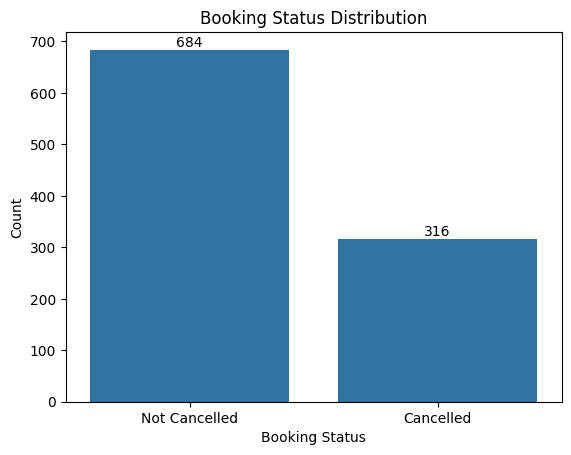

In [17]:
#Univariate Analysis of Booking Status Distribution
# Countplot is used to visualize the frequency of each category
# Here, it shows number of cancelled vs non-cancelled bookings(Booking Status)

ax = sns.countplot(x='Booking Status', data=df)   #store in ax
# Replace 0 and 1 with meaningful labels
plt.xticks([0,1], ['Not Cancelled','Cancelled'])
# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
#Add title,xlabel,ylabel
plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Count")
plt.show()


## Booking Status Insight
Out of total bookings, 684 bookings were not cancelled while 316 bookings were cancelled.

This indicates that the majority of customers complete their bookings successfully. 
However, a significant portion (around 31.6%) of bookings are cancelled, which suggests 
that cancellation is an important factor to consider in hotel booking analysis.

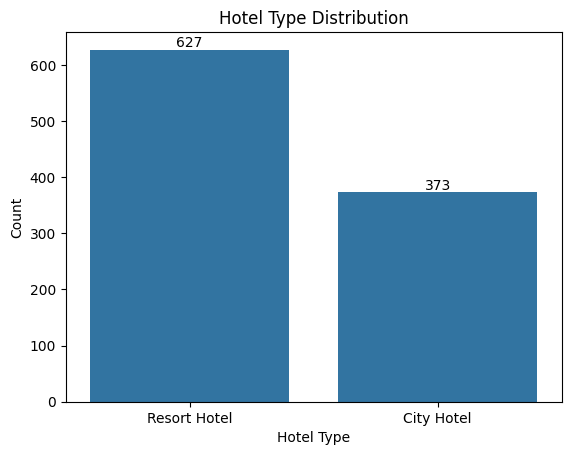

In [19]:
#Univariate Analysis of Hotel Type Distribution
# Countplot to show number of bookings for each hotel type
ax = sns.countplot(x='Hotel', data=df)
# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Hotel Type Distribution")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.show()